# Import libraries

> Add blockquote



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import plotly.express as px
import plotly.graph_objects as go

# LOAD DATASET

In [ ]:
df = pd.read_csv("/content/sample_data/lending_club_loan_two.csv")
print(df.head())
print("\nDataset Info:")
print(df.info())

   loan_amnt        term  int_rate  installment grade sub_grade  \
0    10000.0   36 months     11.44       329.48     B        B4   
1     8000.0   36 months     11.99       265.68     B        B5   
2    15600.0   36 months     10.49       506.97     B        B3   
3     7200.0   36 months      6.49       220.65     A        A2   
4    24375.0   60 months     17.27       609.33     C        C5   

                 emp_title emp_length home_ownership  annual_inc  ...  \
0                Marketing  10+ years           RENT    117000.0  ...   
1          Credit analyst     4 years       MORTGAGE     65000.0  ...   
2             Statistician   < 1 year           RENT     43057.0  ...   
3          Client Advocate    6 years           RENT     54000.0  ...   
4  Destiny Management Inc.    9 years       MORTGAGE     55000.0  ...   

  open_acc pub_rec revol_bal revol_util total_acc  initial_list_status  \
0     16.0     0.0   36369.0       41.8      25.0                    w   
1     17.0

# SELECT IMPORTANT COLUMNS

In [22]:
selected_columns = [
    'loan_amnt',
    'term',
    'int_rate',
    'annual_inc',
    'emp_length',
    'home_ownership',
    'purpose',
    'grade',
    'loan_status'
]

df = df[selected_columns].copy()

# DATA CLEANING

In [34]:
print("\nMissing Values:")
print(df.isnull().sum())
df.dropna(inplace=True)
df['int_rate'] = df['int_rate'].astype(float)
if df['term'].dtype == 'object':
    df['term'] = df['term'].apply(lambda term: int(term.replace(' months', '')))
if df['emp_length'].dtype == 'object':
    df['emp_length'] = df['emp_length'].replace({'10+ years': '10', '< 1 year': '0', '1 year': '1', '2 years': '2', '3 years': '3', '4 years': '4', '5 years': '5', '6 years': '6', '7 years': '7', '8 years': '8', '9 years': '9'})
df['emp_length'] = df['emp_length'].astype(int)

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['loan_status_num'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})



Missing Values:
loan_amnt          0
term               0
int_rate           0
annual_inc         0
emp_length         0
home_ownership     0
purpose            0
grade              0
loan_status        0
Risk_Level         0
loan_status_num    0
dtype: int64


# DESCRIPTIVE STATISTICS

In [23]:
print("\nAverage Loan Amount:")
print(df['loan_amnt'].mean())

print("\nAverage Annual Income:")
print(df['annual_inc'].mean())

print("\nInterest Rate Statistics:")
print(df['int_rate'].describe())


Average Loan Amount:
14219.120802827569

Average Annual Income:
74627.6687036102

Interest Rate Statistics:
count    7922.000000
mean       13.635514
std         4.474022
min         5.320000
25%        10.490000
50%        13.330000
75%        16.490000
max        28.990000
Name: int_rate, dtype: float64


# DEFAULT BEHAVIOR ANALYSIS

In [ ]:
default_counts = df['loan_status'].value_counts()

plt.figure(figsize=(6,5))
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

print("\nLoan Status Count:")
print(default_counts)

# GROUP BASED ANALYSIS

In [ ]:
income_default = df.groupby('loan_status')['annual_inc'].mean()
print("\nIncome vs Loan Status:")
print(income_default)
emp_default = df.groupby('loan_status')['emp_length'].mean()
print("\nEmployment Length vs Loan Status:")
print(emp_default)
home_default = pd.crosstab(df['home_ownership'], df['loan_status'])
print("\nHome Ownership vs Default:")
print(home_default)
purpose_default = pd.crosstab(df['purpose'], df['loan_status'])
print("\nPurpose vs Default:")
print(purpose_default)

# RELATIONSHIP ANALYSIS

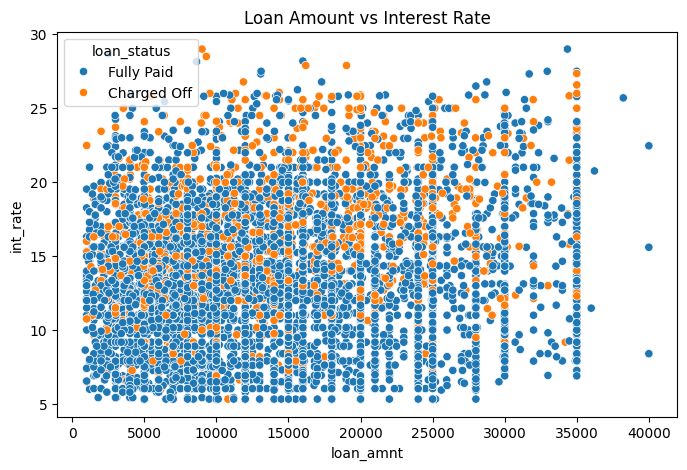

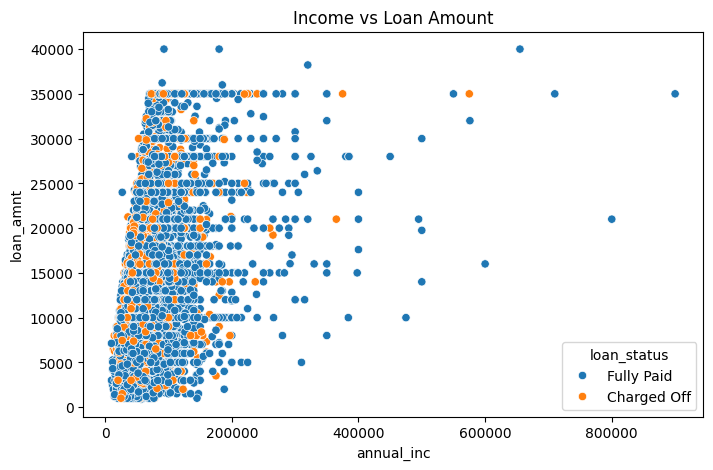

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='loan_amnt', y='int_rate', hue='loan_status', data=df)
plt.title("Loan Amount vs Interest Rate")
plt.show()
plt.figure(figsize=(8,5))
sns.scatterplot(x='annual_inc', y='loan_amnt', hue='loan_status', data=df)
plt.title("Income vs Loan Amount")
plt.show()

# HISTOGRAMS

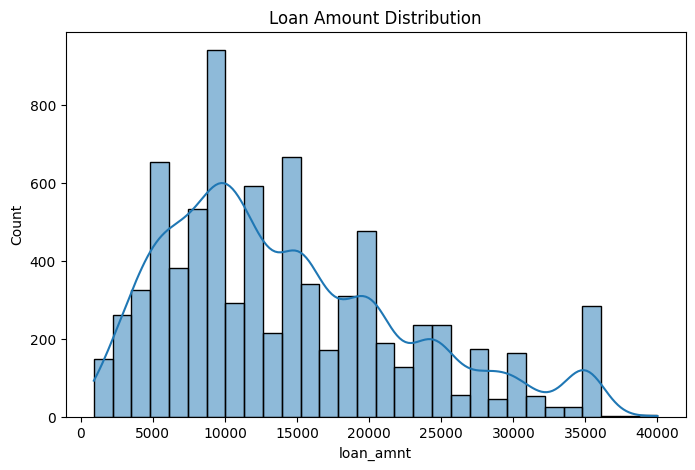

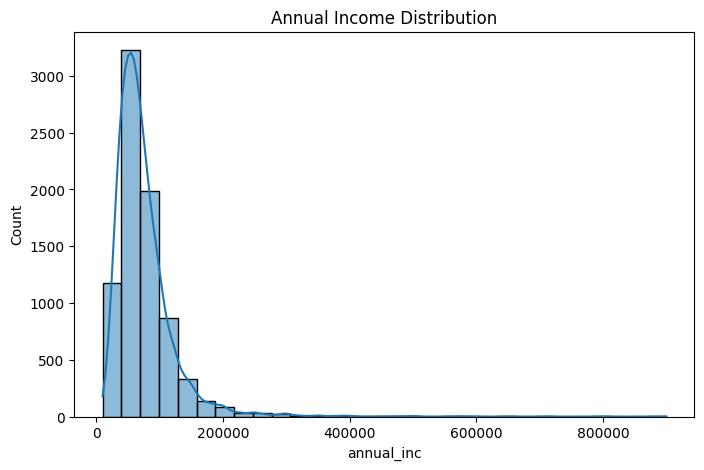

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['loan_amnt'], bins=30, kde=True)
plt.title("Loan Amount Distribution")
plt.show()
plt.figure(figsize=(8,5))
sns.histplot(df['annual_inc'], bins=30, kde=True)
plt.title("Annual Income Distribution")
plt.show()

# BOX PLOTS

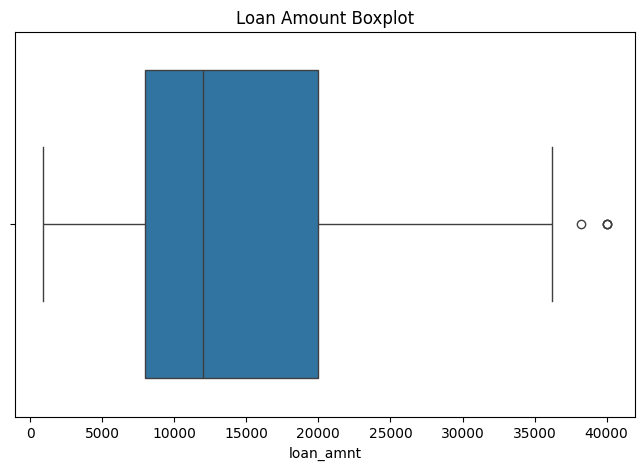

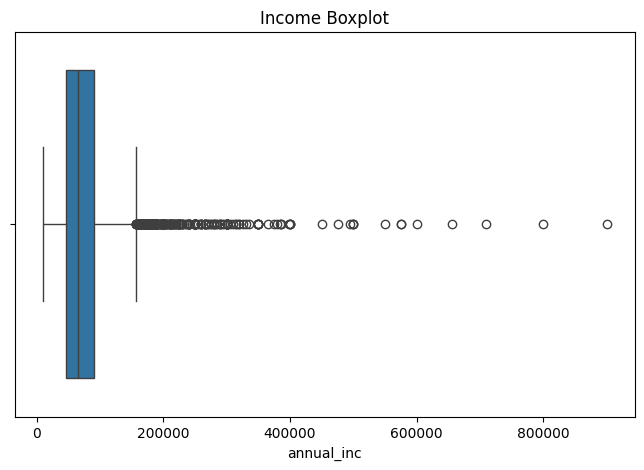

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['loan_amnt'])
plt.title("Loan Amount Boxplot")
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(x=df['annual_inc'])
plt.title("Income Boxplot")
plt.show()

# CORRELATION HEATMAP

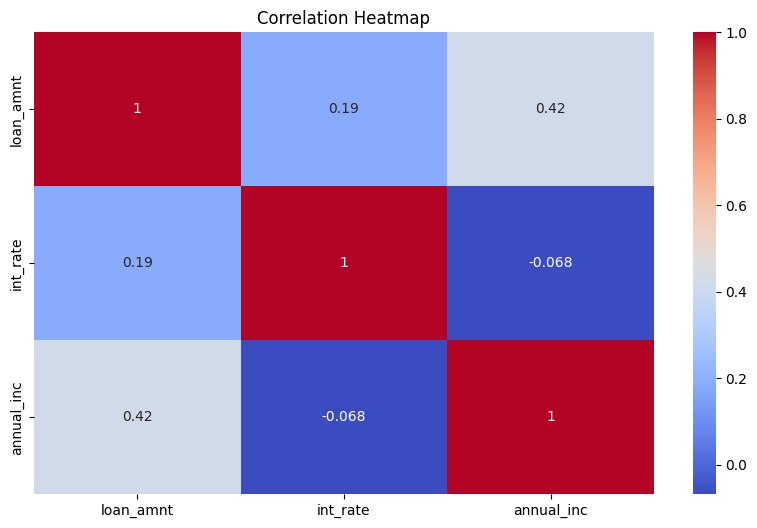

In [27]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# RISK ANALYSIS

In [28]:
def classify_risk(rate):
    if rate < 10:
        return "Low Risk"
    elif rate < 20:
        return "Medium Risk"
    else:
        return "High Risk"

df['Risk_Level'] = df['int_rate'].apply(classify_risk)

print("\nRisk Level Counts:")
print(df['Risk_Level'].value_counts())


Risk Level Counts:
Risk_Level
Medium Risk    5455
Low Risk       1827
High Risk       640
Name: count, dtype: int64


# LINEAR REGRESSION

In [35]:
X = df[['annual_inc', 'int_rate', 'term']]
y = df['loan_amnt']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# MODEL EVALUATION

In [36]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Evaluation")
print("----------------------")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


Model Evaluation
----------------------
R2 Score: 0.3108041968793678
MAE: 5307.412571544218
RMSE: 6884.973059424708


# RESIDUAL ANALYSIS

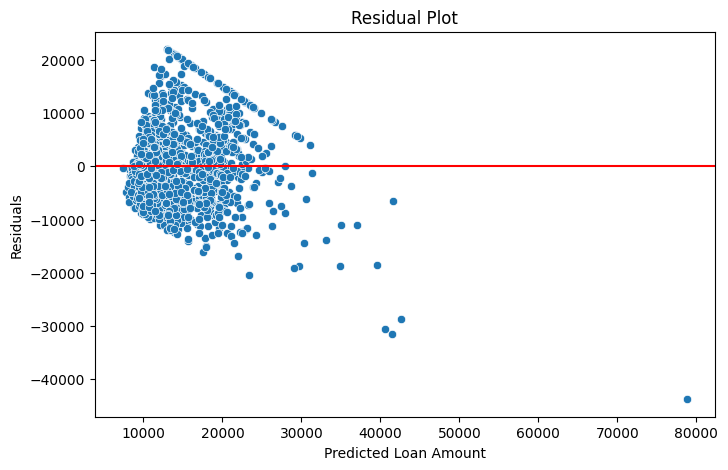

In [37]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red')
plt.title("Residual Plot")
plt.xlabel("Predicted Loan Amount")
plt.ylabel("Residuals")
plt.show()

# PLOTLY DASHBOARD

In [38]:
fig1 = px.scatter(
    df,
    x='annual_inc',
    y='loan_amnt',
    color='loan_status',
    title='Income vs Loan Amount'
)

fig1.show()
fig2 = px.histogram(
    df,
    x='loan_amnt',
    color='loan_status',
    title='Loan Amount Distribution'
)

fig2.show()
fig3 = px.box(
    df,
    x='loan_status',
    y='int_rate',
    color='loan_status',
    title='Interest Rate vs Loan Status'
)

fig3.show()
fig4 = px.bar(
    df,
    x='home_ownership',
    color='loan_status',
    title='Default Comparison by Home Ownership'
)

fig4.show()


# FINAL INSIGHTS

In [ ]:
print("\n================ FINAL INSIGHTS ================")

print("""
1. Higher interest rates are associated with higher default risk.

2. Borrowers with lower annual income show increased default probability.

3. Certain loan purposes have higher default counts.

4. Employment length influences repayment capability.

5. Linear Regression helps predict loan amount using:
   - Annual Income
   - Interest Rate
   - Loan Term

6. Dashboard visualizations help banks identify:
   - High-risk borrowers
   - Loan trends
   - Financial behavior patterns
""")